In [54]:
%run train.ipynb

['Female' 'Male']
Class balance before SMOTE:
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Class balance after SMOTE:
churn
1    0.5
0    0.5
Name: proportion, dtype: float64
3.3.0


**Evaluation**

In [55]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
import matplotlib.pyplot as plt

In [56]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

Confusion Matrix:
[[1138  455]
 [ 112  295]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1593
       Churn       0.39      0.72      0.51       407

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.66      2000
weighted avg       0.81      0.72      0.74      2000

ROC-AUC: 0.7733


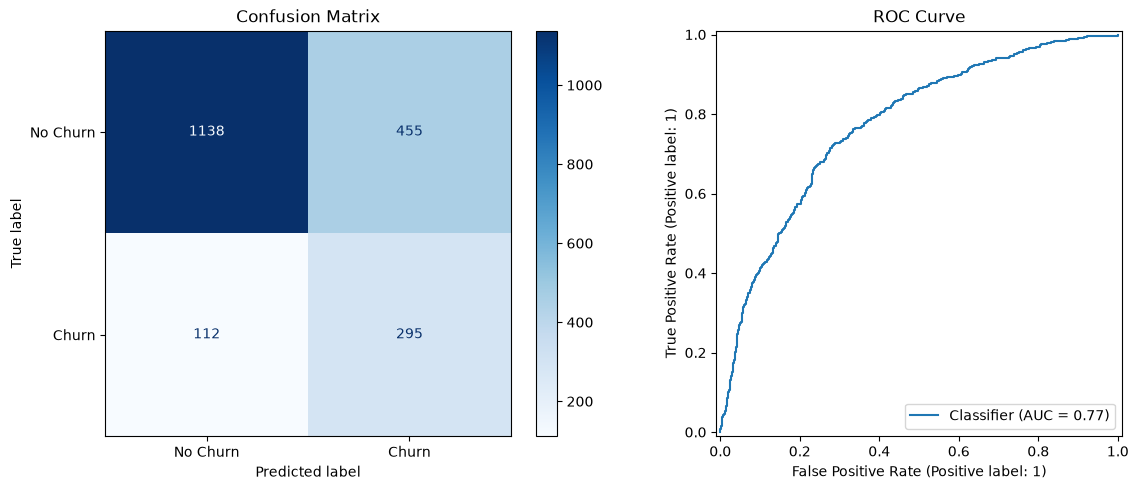

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

**Evaluating the random forest model**

In [58]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
import matplotlib.pyplot as plt

In [59]:
y_pred = rf_model.predict(X_test_raw)
y_pred_proba = rf_model.predict_proba(X_test_raw)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

Confusion Matrix:
[[1305  288]
 [ 123  284]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.82      0.86      1593
       Churn       0.50      0.70      0.58       407

    accuracy                           0.79      2000
   macro avg       0.71      0.76      0.72      2000
weighted avg       0.83      0.79      0.81      2000

ROC-AUC: 0.8407


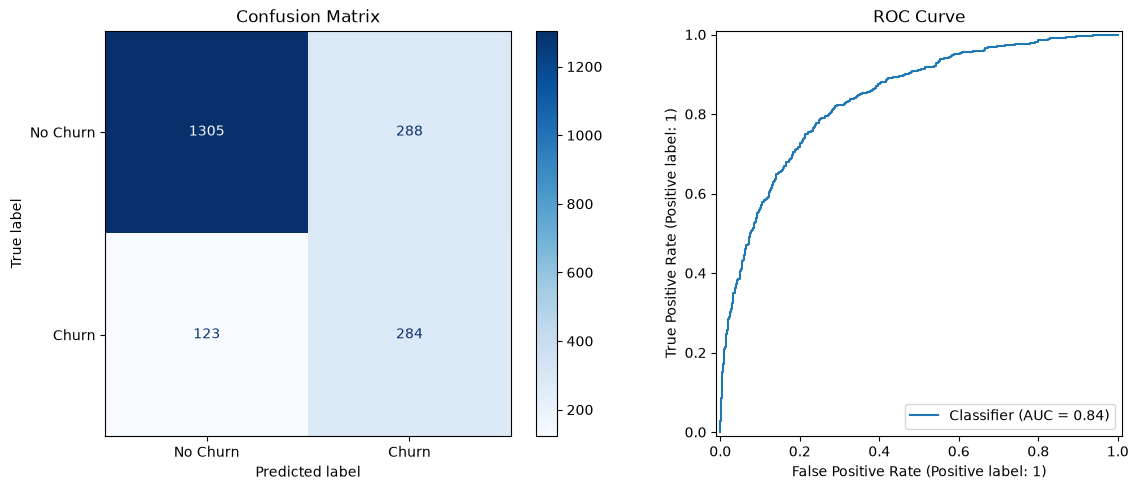

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

**Evaluating the Gradient Boosting model**

In [61]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [62]:
y_pred = gb_model.predict(X_test_raw)
y_prob = gb_model.predict_proba(X_test_raw)[:, 1]

# Evaluation Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Confusion Matrix:
[[1274  319]
 [ 114  293]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      0.80      0.85      1593
       Churn       0.48      0.72      0.58       407

    accuracy                           0.78      2000
   macro avg       0.70      0.76      0.71      2000
weighted avg       0.83      0.78      0.80      2000

Accuracy: 0.7835
Precision: 0.4788
Recall: 0.7199
F1-Score: 0.5751
ROC-AUC: 0.8523


**Evaluating the Xgboost model**

In [63]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

# Individual Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Confusion Matrix:
[[1593    0]
 [ 406    1]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      1.00      0.89      1593
       Churn       1.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.90      0.50      0.45      2000
weighted avg       0.84      0.80      0.71      2000

Accuracy : 0.7970
Precision: 1.0000
Recall   : 0.0025
F1-Score : 0.0049
ROC-AUC  : 0.5171


**From the evaluation of the Candidate models its between random forest and gradient boosting**